In [1]:
pip install mysql-connector-python pandas sqlalchemy pymysql matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import mysql.connector
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="WJ28@krhps",
    database="finance" 
)

print("Database Connected Successfully")

Database Connected Successfully


In [3]:
# Create cursor
cursor = conn.cursor()

# Get all table names
cursor.execute("SHOW TABLES")

# Store all DataFrames in dictionary
tables = {}

# Loop through tables
for table in cursor.fetchall():
    
    table_name = table[0]
    
    query = f"SELECT * FROM {table_name}"
    
    # Load table into dataframe
    tables[table_name] = pd.read_sql(query, conn)

    print(f"{table_name} loaded successfully")

accounts loaded successfully
claims loaded successfully
credit_cards loaded successfully
customers loaded successfully
frauds loaded successfully
insurance loaded successfully
loan_payments loaded successfully
loans loaded successfully
policies loaded successfully
transactions loaded successfully


C:\Users\ABC\AppData\Local\Temp\ipykernel_21276\1275943725.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables[table_name] = pd.read_sql(query, conn)


In [4]:
customer_df = tables['customers']
account_df = tables['accounts']
claim_df = tables['claims']
loan_df = tables['loans']
loan_payments_df = tables['loan_payments']
fraud_df = tables['frauds']
creditcard_df = tables['credit_cards']
insurance_df = tables['insurance']
policies_df = tables['policies']
transaction_df = tables['transactions']

## Insights for the data

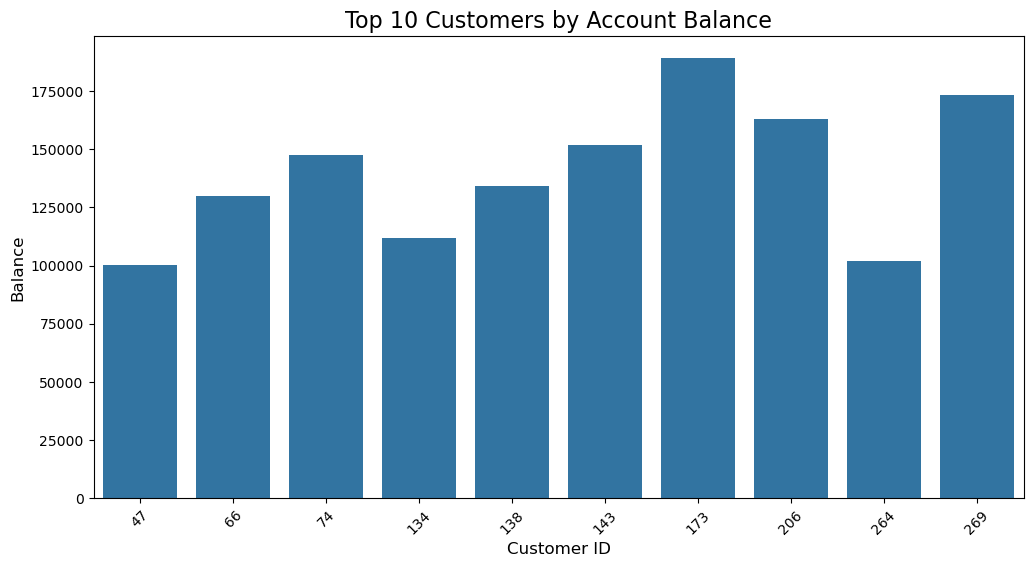

In [5]:
# 1. Which customers maintain the highest balances?

top_customers = account_df.nlargest(10, 'Balance')

top_customers[['Customer_ID', 'Balance']]

# Insight-> High-balance customers are valuable for cross-selling loans, insurance, and investments.

# Select Top 10 Customers
top_customers = account_df.nlargest(10, 'Balance')

# Create Figure
plt.figure(figsize=(12,6))


# Bar Chart Visualization
sns.barplot(
    x='Customer_ID',
    y='Balance',
    data=top_customers
)

plt.title("Top 10 Customers by Account Balance", fontsize=16)

plt.xlabel("Customer ID", fontsize=12)

plt.ylabel("Balance", fontsize=12)

plt.xticks(rotation=45)

plt.show()

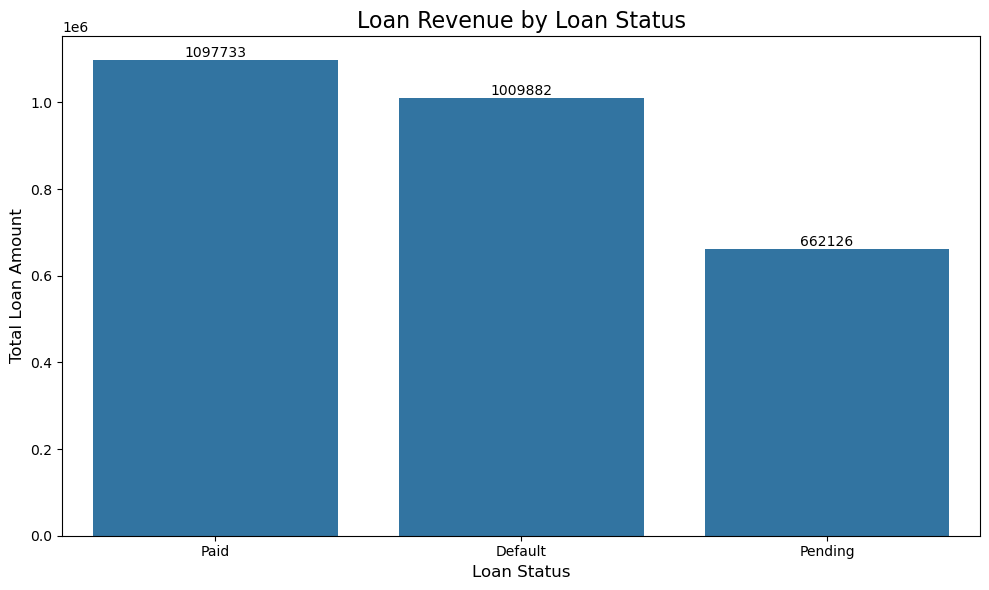

In [6]:
# 2. Which loan type generates the highest revenue?

loan_revenue = loan_df.groupby('Loan_Status')['Loan_Amount'].sum()

loan_revenue.sort_values(ascending=False)

# Insight-> Company can focus marketing on profitable loan products.


# Bar Chart Visualization
# Calculate loan revenue
loan_revenue = loan_df.groupby('Loan_Status')['Loan_Amount'].sum().sort_values(ascending=False)

loan_revenue = loan_revenue.reset_index()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x='Loan_Status',
    y='Loan_Amount',
    data=loan_revenue
)

for i in ax.containers:
    ax.bar_label(i, fmt='%.0f')

plt.title("Loan Revenue by Loan Status", fontsize=16)

plt.xlabel("Loan Status", fontsize=12)

plt.ylabel("Total Loan Amount", fontsize=12)

plt.tight_layout()

plt.show()

2769741.1500000004


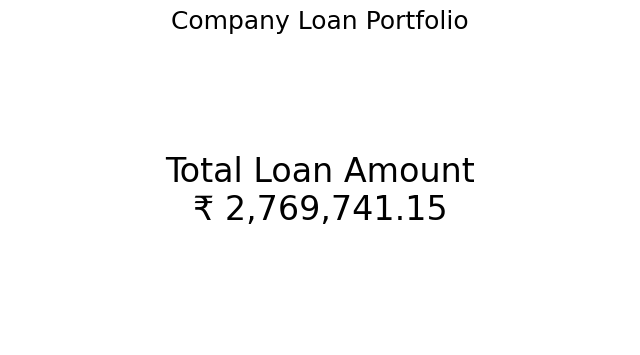

In [7]:
# 3. What is the total loan amount issued by the company?

total_loan = loan_df['Loan_Amount'].sum()

print(total_loan)

# Insight-> Higher lending increases interest revenue but also risk.


# Professional KPI Style Visualization
# Total loan amount
total_loan = loan_df['Loan_Amount'].sum()

plt.figure(figsize=(8,4))

plt.axis('off')

plt.text(
    0.5,
    0.5,
    f'Total Loan Amount\n₹ {total_loan:,.2f}',
    fontsize=24,
    ha='center',
    va='center'
)

plt.title("Company Loan Portfolio", fontsize=18)

plt.show()

Policy_Type
Loan       7
Silver     7
Gold       5
Savings    4
Name: count, dtype: int64


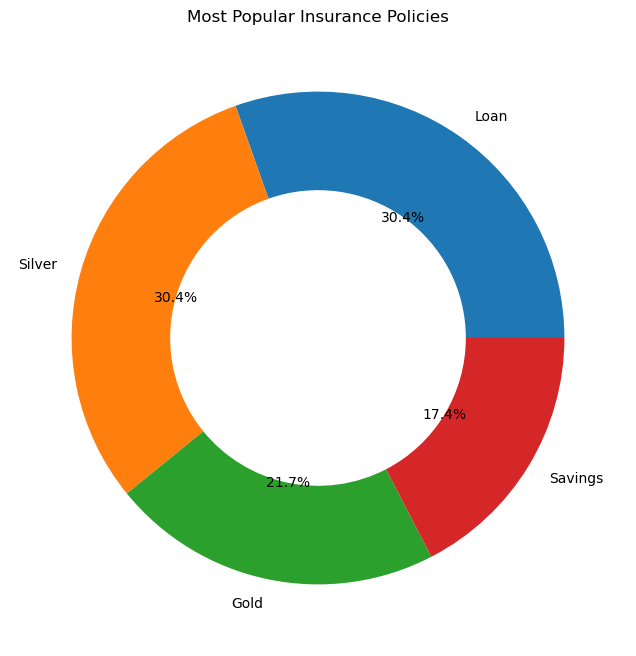

In [8]:
# 4. Which insurance policy type is most popular?

popular_policy = policies_df['Policy_Type'].value_counts()

print(popular_policy)

# Insight-> Helps company improve profitable insurance offerings.


# Donut Chart
popular_policy = policies_df['Policy_Type'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    popular_policy,
    labels=popular_policy.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4}
)

plt.title("Most Popular Insurance Policies")

plt.show()

359095.14


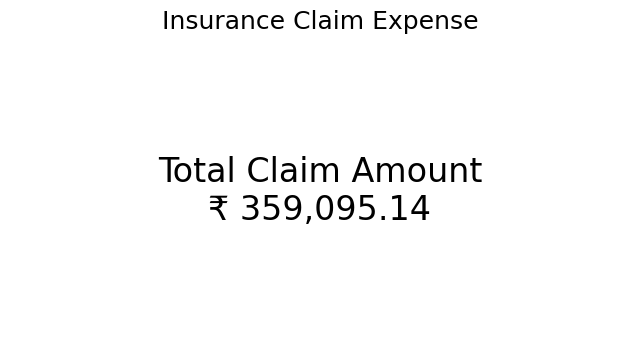

In [9]:
# 5. What is the total claim amount paid by the company?

total_claim_amount = claim_df['Claim_Amount'].sum()

print(total_claim_amount)

# Insight-> Higher claims reduce company profitability.


# KPI Style Visualization
total_claim_amount = claim_df['Claim_Amount'].sum()

plt.figure(figsize=(8,4))

plt.axis('off')

plt.text(
    0.5,
    0.5,
    f'Total Claim Amount\n₹ {total_claim_amount:,.2f}',
    fontsize=24,
    ha='center',
    va='center'
)

plt.title("Insurance Claim Expense", fontsize=18)

plt.show()

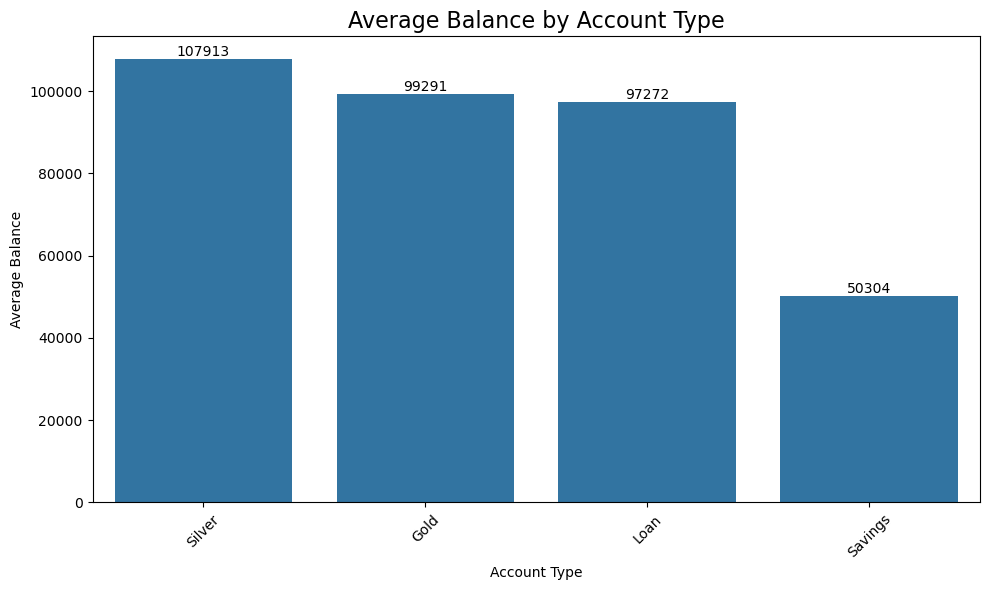

In [10]:
# 6. Which account type has the highest average balance?

avg_balance = account_df.groupby(
    'Account_Type'
)['Balance'].mean()

avg_balance.sort_values(ascending=False)

# Insight-> Shows most profitable account category.


# Bar Chart Visualization
avg_balance = account_df.groupby(
    'Account_Type'
)['Balance'].mean().sort_values(ascending=False)

avg_balance = avg_balance.reset_index()

avg_balance.columns = ['Account_Type', 'Average_Balance']

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x='Account_Type',
    y='Average_Balance',
    data=avg_balance
)

for i in ax.containers:
    ax.bar_label(i, fmt='%.0f')

plt.title("Average Balance by Account Type", fontsize=16)

plt.xlabel("Account Type")

plt.ylabel("Average Balance")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

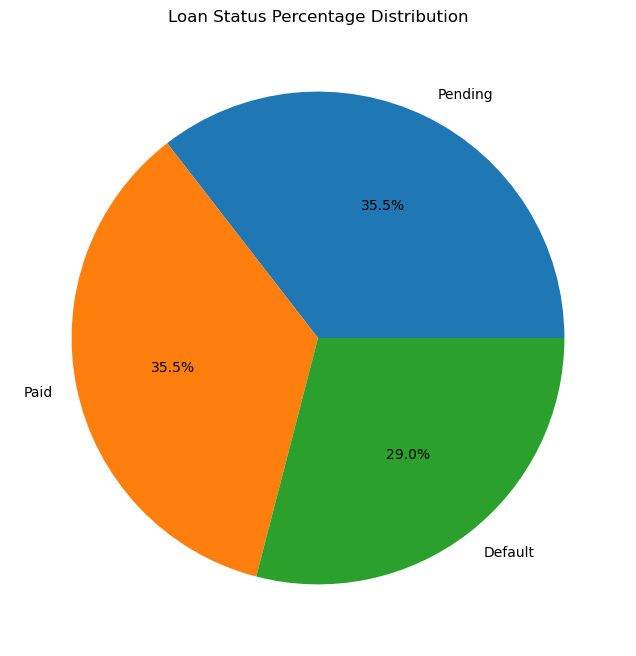

In [11]:
# 7. Which loan status causes maximum business risk?

loan_df['Loan_Status'].value_counts()

# Insight-> Rejected/default loans indicate risk issues.


# Pie Chart Visualization
loan_status = loan_df['Loan_Status'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    loan_status,
    labels=loan_status.index,
    autopct='%1.1f%%'
)

plt.title("Loan Status Percentage Distribution")

plt.show()

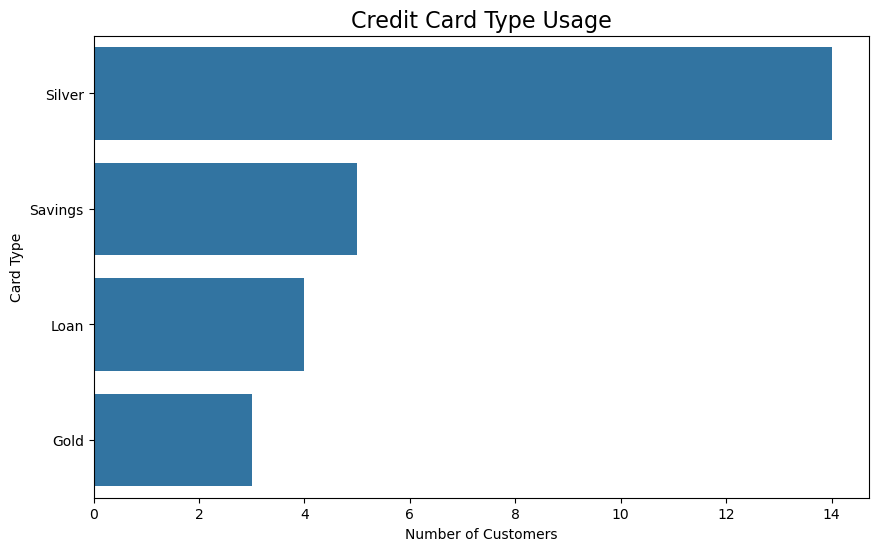

In [12]:
# 8. Which credit card type is most used?

creditcard_df['Card_Type'].value_counts()

# Insight-> Helps improve card marketing strategies.


# Horizontal Bar Chart
card_usage = creditcard_df['Card_Type'].value_counts()

card_usage = card_usage.reset_index()

card_usage.columns = ['Card_Type', 'Count']

plt.figure(figsize=(10,6))

sns.barplot(
    x='Count',
    y='Card_Type',
    data=card_usage
)

plt.title("Credit Card Type Usage", fontsize=16)

plt.xlabel("Number of Customers")

plt.ylabel("Card Type")

plt.show()

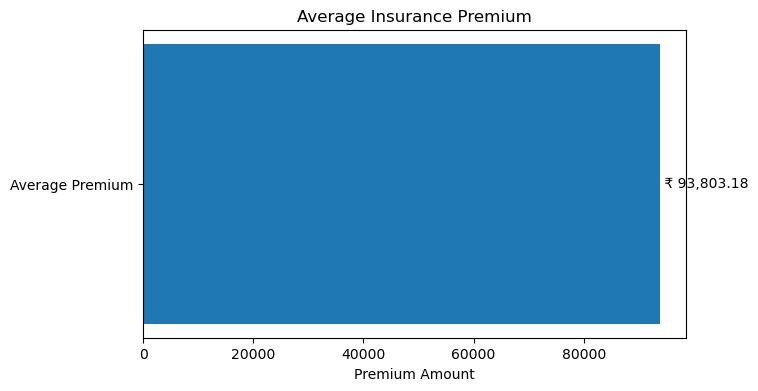

In [13]:
# 9. What is the average insurance premium?

insurance_df['Insurance_Premium'].mean()

# Insight-> Measures recurring insurance revenue.


# Gauge Style Visualization
avg_premium = insurance_df['Insurance_Premium'].mean()

plt.figure(figsize=(7,4))

plt.barh(
    ['Average Premium'],
    [avg_premium]
)

plt.title("Average Insurance Premium")

plt.xlabel("Premium Amount")

plt.text(
    avg_premium,
    0,
    f' ₹ {avg_premium:,.2f}',
    va='center'
)

plt.show()

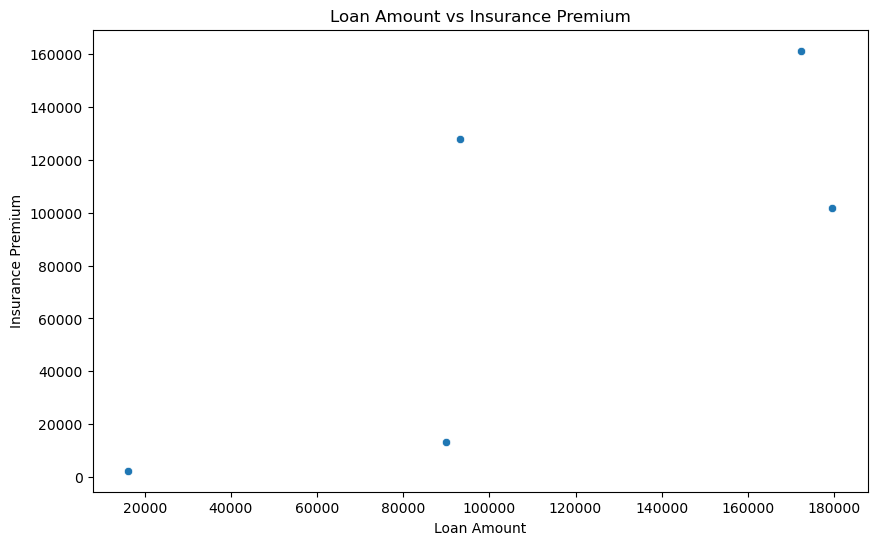

In [14]:
# 10. Which customers have both loans and insurance?

cross_sell = pd.merge(
    loan_df,
    insurance_df,
    on='Customer_ID'
)

cross_sell.head()

# Insight-> These customers are highly valuable.


# Loan Amount vs Insurance Premium (Shows relationship between loans and insurance spending)
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Loan_Amount',
    y='Insurance_Premium',
    data=cross_sell
)

plt.title("Loan Amount vs Insurance Premium")

plt.xlabel("Loan Amount")

plt.ylabel("Insurance Premium")

plt.show()

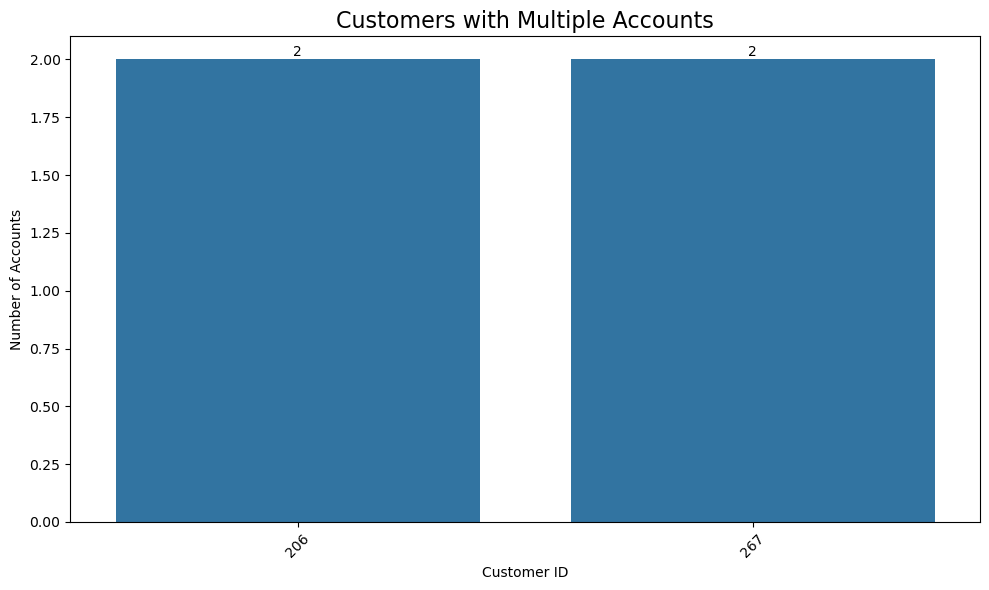

In [15]:
# 11. Which customers have multiple accounts?

multiple_accounts = account_df['Customer_ID'].value_counts()

multiple_accounts[multiple_accounts > 1]

# Insight-> Customers with multiple accounts are highly engaged.


# Bar Chart Visualization
multiple_accounts = account_df['Customer_ID'].value_counts()

multiple_accounts = multiple_accounts[
    multiple_accounts > 1
]

multiple_accounts = multiple_accounts.reset_index()

multiple_accounts.columns = [
    'Customer_ID',
    'Number_of_Accounts'
]

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x='Customer_ID',
    y='Number_of_Accounts',
    data=multiple_accounts
)

for i in ax.containers:
    ax.bar_label(i)

plt.title(
    "Customers with Multiple Accounts",
    fontsize=16
)

plt.xlabel("Customer ID")

plt.ylabel("Number of Accounts")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()